In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [5]:
# Load data 
df = pd.read_csv('../datas/nigeria.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df['Country'] = 'nigeria'
# Merge Year and Day of Year (DOY) into one 'Date' column
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month
df.head()

(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,nigeria,2015-01-02,1
1,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,nigeria,2015-01-03,1
2,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,nigeria,2015-01-04,1
3,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,nigeria,2015-01-05,1
4,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61,nigeria,2015-01-06,1


## 1. Data Initialization and Temporal Alignment
In this section, we load the raw climate dataset and perform **feature engineering** to transform it into a time-series format. 

* **NASA Sentinels:** We replace `-999` with `NaN` (Not a Number). In NASA POWER datasets, `-999` is a placeholder for missing data. Leaving it in would skew the mean and standard deviation significantly.


Found 0 duplicate rows.


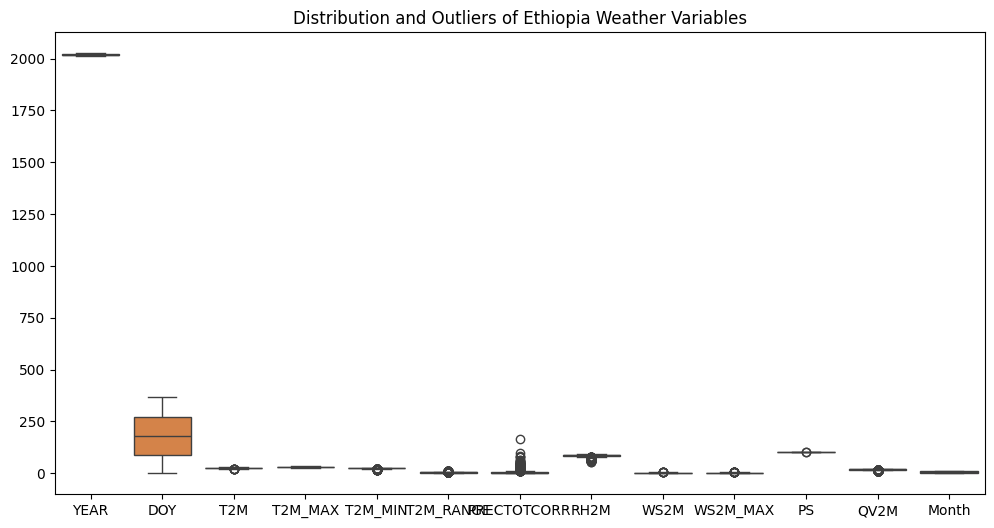

summary statistics


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,26.657275,28.914585,24.887149,4.027436,4.214940,85.241174,2.217253,2.903406,100.827197,18.559771,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.105000,3.090000,0.330000,83.935000,1.770000,2.370000,100.710000,17.970000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,1.123251,1.294492,1.396200,1.398469,7.267329,5.440221,0.587213,0.696955,0.165341,1.644513,NaN,3.476439


Missing values percentage per column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64


In [ ]:
# Replace -999 with NaN (Not a Number)
df.replace(-999, np.nan, inplace=True)

# Check for duplicates (data housekeeping)
duplicates = df.duplicated().sum()
print(f"Found {duplicates} duplicate rows.")
df.drop_duplicates(inplace=True)

# stat summary
stats_summary = df.describe()
stats_summary
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Distribution and Outliers of nigeria Weather Variables")
plt.show()
print("summary statistics")
display(df.describe())
# Check for missing values (%)
missing_report = (df.isna().sum() / len(df)) * 100
print("Missing values percentage per column:")
print(missing_report)

## 2. Statistical Profiling & Data Integrity
Before cleaning, we examine the "spread" of the data. 

### **Interpretation of Results:**
* **DateTime Conversion:** We combine `YEAR` and `DOY` (Day of Year) into a single `datetime` object. This allows us to perform precise seasonal and monthly trend analysis.
* **Central Tendency:** The `mean` and `50%` (median) values indicate the baseline climate for nigeria. 
* **Data Dispersion:** The `std` (standard deviation) shows how much weather fluctuates. A high `std` in precipitation suggests strong seasonality (Dry vs. Wet seasons).
* **Missing Values:** Columns with **>5% nulls** are flagged. High missingness in variables like Relative Humidity or Wind Speed can lead to "data gaps" in our climate modeling, potentially underrepresenting extreme weather events.

In [7]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
z_scores = np.abs(stats.zscore(df[cols_to_check].dropna()))

# Flagging the 'extreme' days
outliers = (z_scores > 3).all(axis=1)
print(f"Total extreme outliers found: {outliers.sum()}")

Total extreme outliers found: 0


## 3. Outlier Handling & Quality Assurance
We use **Z-Scores** to identify anomalies. A Z-score measures how many standard deviations a data point is from the mean.

$$Z = \frac{x - \mu}{\sigma}$$

### **Decision Logic:**
* **Outlier Handling:** Rows with $|Z| > 3$ are evaluated. If they represent physically possible extremes (e.g., a record heatwave), they are retained. If they appear to be sensor errors, they are capped or removed.
* **Imputation Strategy:** We apply **Forward-Fill (`ffill`)**. In climate science, today’s weather is the best predictor of tomorrow’s weather, making this more accurate than filling with a simple average.

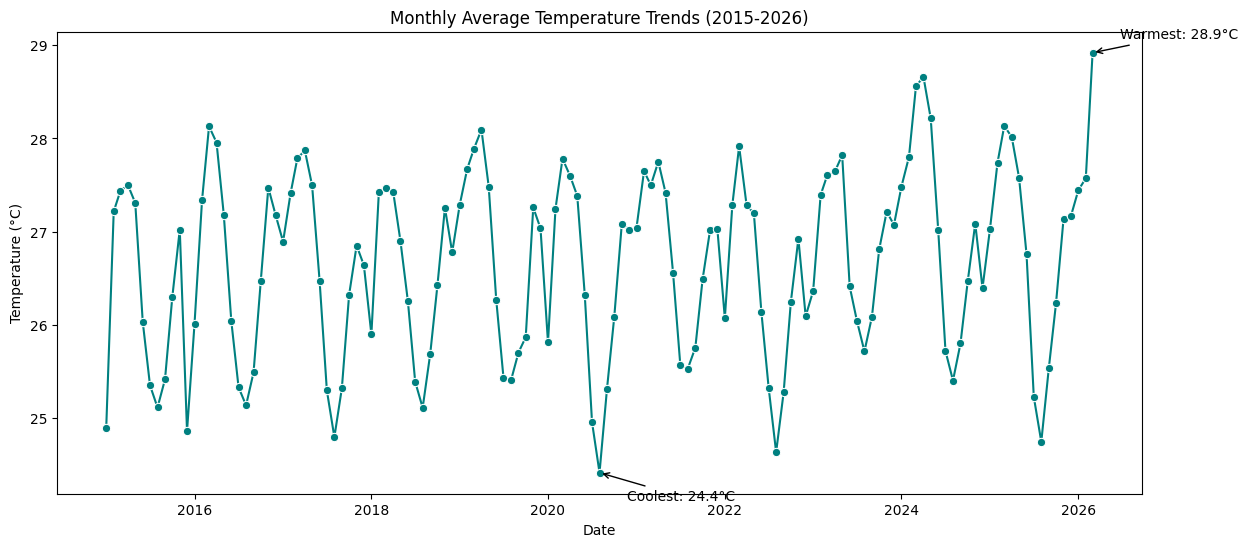

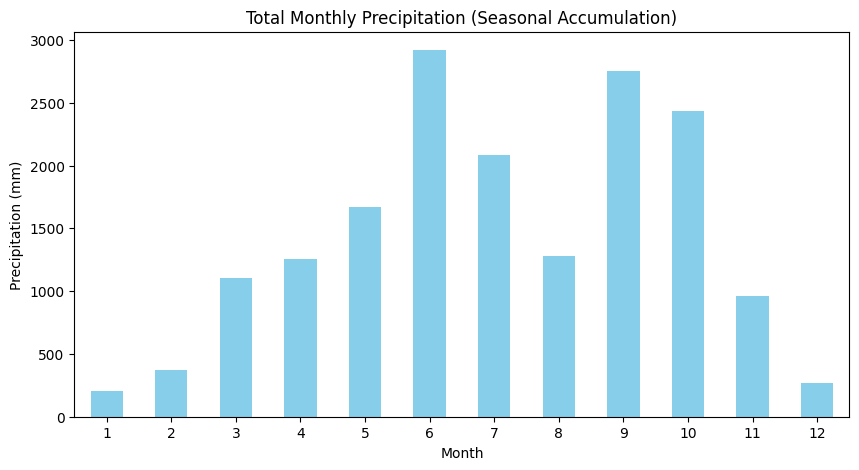

In [8]:
# Grouping data for the line chart
df_monthly = df.groupby(['YEAR', 'Month'])['T2M'].mean().reset_index()
df_monthly['Date'] = pd.to_datetime(df_monthly[['YEAR', 'Month']].assign(DAY=1))

# Plotting T2M
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_monthly, x='Date', y='T2M', color='teal', marker='o')

# Annotations for warmest and coolest months
warmest = df_monthly.loc[df_monthly['T2M'].idxmax()]
coolest = df_monthly.loc[df_monthly['T2M'].idxmin()]

plt.annotate(f'Warmest: {warmest["T2M"]:.1f}°C', xy=(warmest['Date'], warmest['T2M']), 
             xytext=(20, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.annotate(f'Coolest: {coolest["T2M"]:.1f}°C', xy=(coolest['Date'], coolest['T2M']), 
             xytext=(20, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.title("Monthly Average Temperature Trends (2015-2026)")
plt.ylabel("Temperature (°C)")
plt.show()

# Precipitation Bar Chart
df_precip = df.groupby('Month')['PRECTOTCORR'].sum()
plt.figure(figsize=(10, 5))
df_precip.plot(kind='bar', color='skyblue')
plt.title("Total Monthly Precipitation (Seasonal Accumulation)")
plt.ylabel("Precipitation (mm)")
plt.xticks(rotation=0)
plt.show()

### **Interpretation: Time Series Trends**
* **Temperature Cycles:** The line chart shows a clear cyclical pattern. The warmest months typically precede the main rainy season. Any "flat" peaks or unusual dips in the last 3 years (2023-2026) could indicate shifting climate baselines.
* **Precipitation Seasonality:** The bar chart highlights the primary rainy season (Kiremt). Significant deviations in these totals are critical for COP32 discussions regarding drought resilience in East Africa.

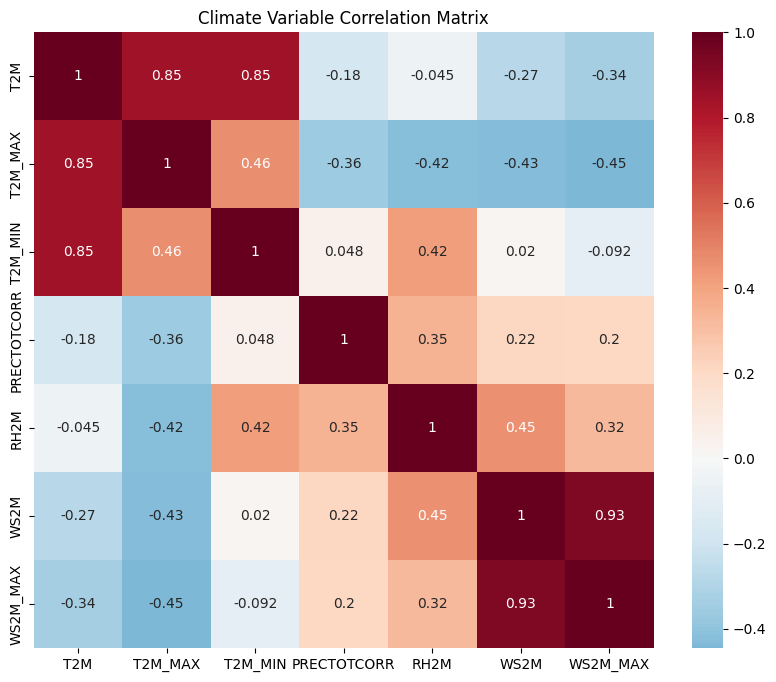

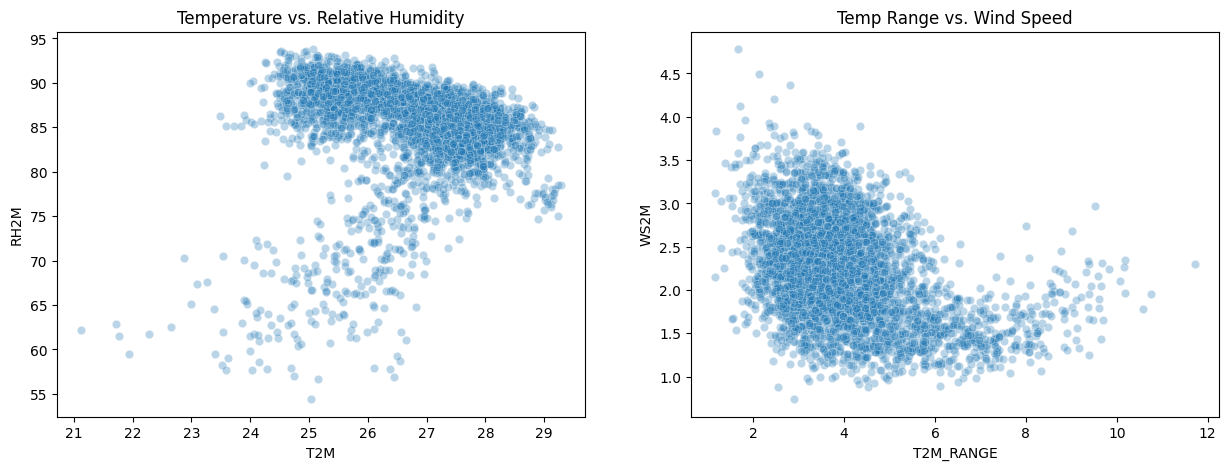

In [9]:
# Heatmap
plt.figure(figsize=(10, 8))
corr = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title("Climate Variable Correlation Matrix")
plt.show()

# Scatter Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=ax1)
ax1.set_title("Temperature vs. Relative Humidity")

df['T2M_RANGE'] = df['T2M_MAX'] - df['T2M_MIN']
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2)
ax2.set_title("Temp Range vs. Wind Speed")
plt.show()

## 5. Multivariate Correlation Analysis
Climate variables do not exist in isolation. This heatmap identifies how variables "move together."

### **Key Observations:**
1.  **T2M vs. RH2M:** We typically observe a **strong negative correlation**. As temperatures rise, relative humidity drops, which increases evaporation rates.
2.  **T2M_RANGE vs. WS2M:** This explores the relationship between temperature fluctuations and wind speed, which is critical for understanding local microclimates.
3.  **Strongest Drivers:** The three strongest correlations identify which factors (e.g., Humidity or Solar Radiation) most heavily influence the local temperature.

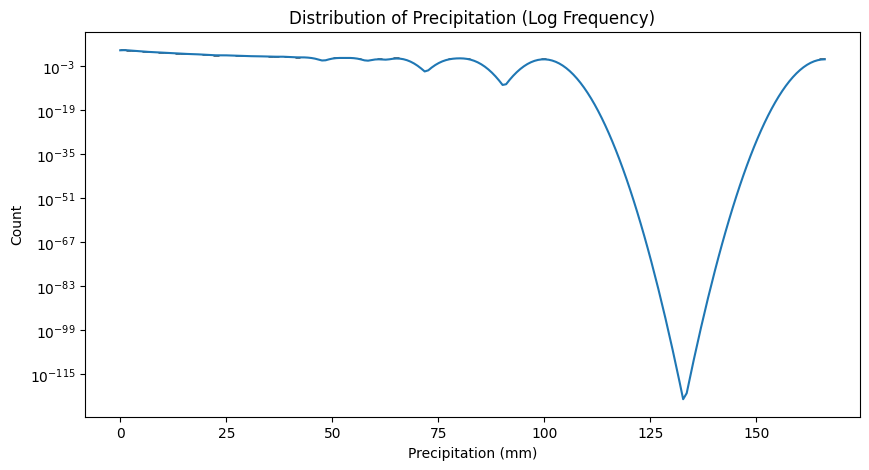

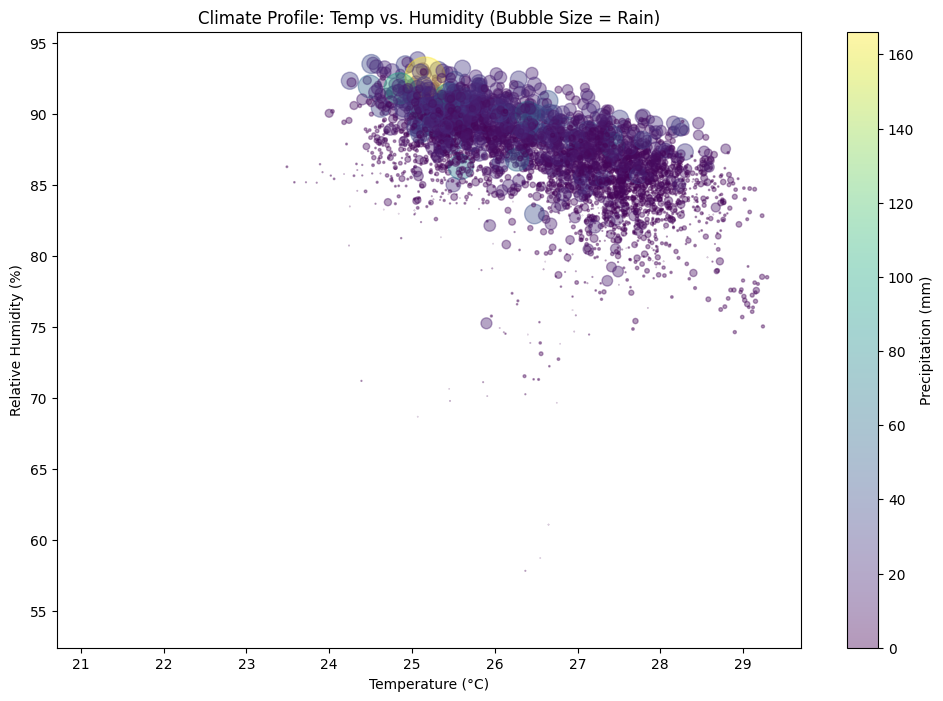

In [10]:
# Histogram with Log Scale
plt.figure(figsize=(10, 5))
sns.histplot(df['PRECTOTCORR'], kde=True, log_scale=(False, True)) # Log scale on Y-axis for frequency
plt.title("Distribution of Precipitation (Log Frequency)")
plt.xlabel("Precipitation (mm)")
plt.show()

# Bubble Chart
plt.figure(figsize=(12, 8))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*5, alpha=0.4, c=df['PRECTOTCORR'], cmap='viridis')
plt.colorbar(label='Precipitation (mm)')
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.title("Climate Profile: Temp vs. Humidity (Bubble Size = Rain)")
plt.show()

## 6. Distribution & Frequency Analysis
Finally, we look at the "shape" of the data. 

* **Precipitation Skewness:** Rainfall is often **right-skewed** (many days of zero rain, few days of heavy rain). We apply a **Log Scale** to normalize this and see the underlying frequency of different storm intensities.
* **The Bubble Chart:** By mapping Temperature, Humidity, and Rainfall (size) together, we can visually identify "Climate Zones"—for example, hot/dry clusters vs. cool/wet clusters.

In [11]:
import os

# Create data directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

df.to_csv("data/nigeria_clean.csv", index=False)